# 과제 1 정답 및 해설 — 헬스케어 보험료 예측 회귀모델

**데이터:** `insurance.csv` (1,338행 × 7열)
**목표:** 개인의 인구통계·건강 정보로 **연간 보험 청구액(`charges`)** 을 예측하는 회귀모델 구현

---

## 순서

| 단계 | 내용 |
|---|---|
| 0 | 라이브러리 및 데이터 로드 |
| 1 | 데이터 이해 (구조·결측치·기술통계) |
| 2 | EDA — 타깃 분포와 변수별 관계 |
| 3 | Train / Test 분리 (**전처리보다 먼저!**) |
| 4 | 전처리 파이프라인 설계 (`ColumnTransformer` + `Pipeline`) |
| 5 | 베이스라인 모델과 교차검증 |
| 6 | 여러 모델 비교 |
| 7 | 하이퍼파라미터 튜닝 (`GridSearchCV`) |
| 8 | 최종 모델 평가 (Test set) |
| 9 | 모델 해석 — 특성 중요도 · 잔차 분석 |
| 10 | 피처 엔지니어링 |

## 0. 라이브러리 및 데이터 로드

재현성(reproducibility)을 위해 `RANDOM_STATE`를 하나의 상수로 고정

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True

df = pd.read_csv("insurance.csv")
print("shape:", df.shape)
df.head()

shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## 1. 데이터 이해

모델링에 들어가기 전에 **반드시** 확인해야 할 세 가지입니다.

1. **자료형(dtype)** — 숫자형인가 범주형인가?
2. **결측치** — 채울 것인가, 버릴 것인가?
3. **기술통계** — 이상치, 단위, 값의 범위(스케일 차이)

In [2]:
df.info()
print("\n--- 결측치 개수 ---")
print(df.isnull().sum())
print("\n--- 중복 행 ---")
print("duplicated:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- 결측치 개수 ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- 중복 행 ---
duplicated: 1


In [3]:
# 수치형 기술통계
display(df.describe().T)

# 범주형 변수의 분포
for col in ["sex", "smoker", "region", "children"]:
    print(f"\n[{col}]")
    print(df[col].value_counts())

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801



[sex]
sex
male      676
female    662
Name: count, dtype: int64

[smoker]
smoker
no     1064
yes     274
Name: count, dtype: int64

[region]
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

[children]
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


### 체크 포인트

1. **결측치 0개, 중복 1행** → 결측치 처리는 불필요. (중복 1건은 실제 다른 사람일 수 있으므로 그대로 둡니다.)
2. `age`(18~64), `bmi`(15.96~53.13), `children`(0~5) → **수치형**
3. `sex`, `smoker`, `region` → **범주형** (문자열이므로 반드시 인코딩 필요)
4. 타깃 `charges`: 평균 13,270 / 중앙값 9,382 / 최댓값 63,770  
  → **평균 > 중앙값**, 최댓값이 매우 큼 = **오른쪽으로 긴 꼬리(right-skewed)** 분포일 가능성이 큼

## 2. EDA — 타깃 분포와 변수별 관계

EDA의 목적은 예쁜 그래프가 아니라 **모델링 전략을 정하는 것**입니다.  

- Q1. 타깃 `charges`의 분포는 정규분포에 가까운가? (선형회귀 가정과 관련)
- Q2. 어떤 변수가 `charges`와 강하게 연관되어 있는가?
- Q3. 변수 간 **상호작용(interaction)** 이 존재하는가? (→ 선형모델 vs 트리모델 선택의 근거)

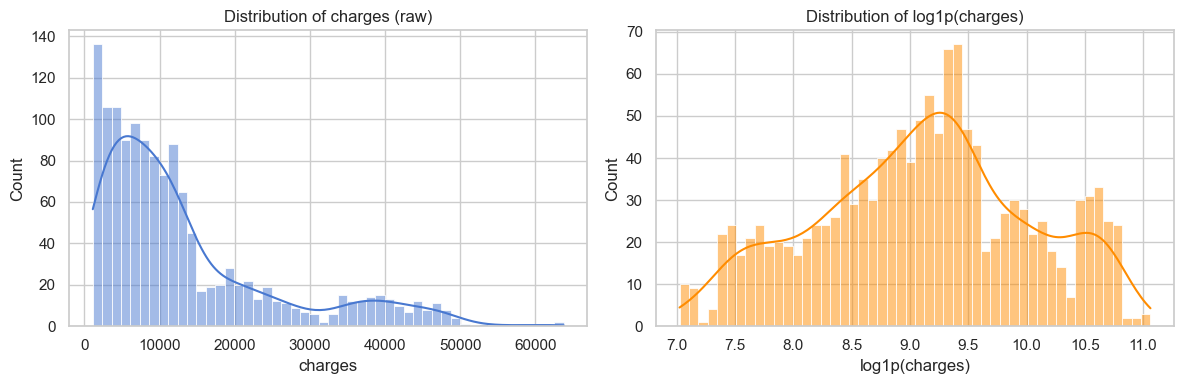

왜도(skewness) - 원본     : 1.516
왜도(skewness) - log1p 변환: -0.09


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["charges"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribution of charges (raw)")
axes[0].set_xlabel("charges")

sns.histplot(np.log1p(df["charges"]), bins=50, kde=True, color="darkorange", ax=axes[1])
axes[1].set_title("Distribution of log1p(charges)")
axes[1].set_xlabel("log1p(charges)")
plt.tight_layout(); plt.show()

print("왜도(skewness) - 원본     :", round(df['charges'].skew(), 3))
print("왜도(skewness) - log1p 변환:", round(np.log1p(df['charges']).skew(), 3))

**Q1 답:** 원본 `charges`는 왜도 ≈ 1.5로 오른쪽 꼬리가 길다.  
`log1p` 변환을 하면 왜도를 크게 줄이는 효과가 있어 선형성을 높일 수 있다.

> 다만, log1p로 변환한 것은 나중에 expm1으로 원복시켜야 한다.

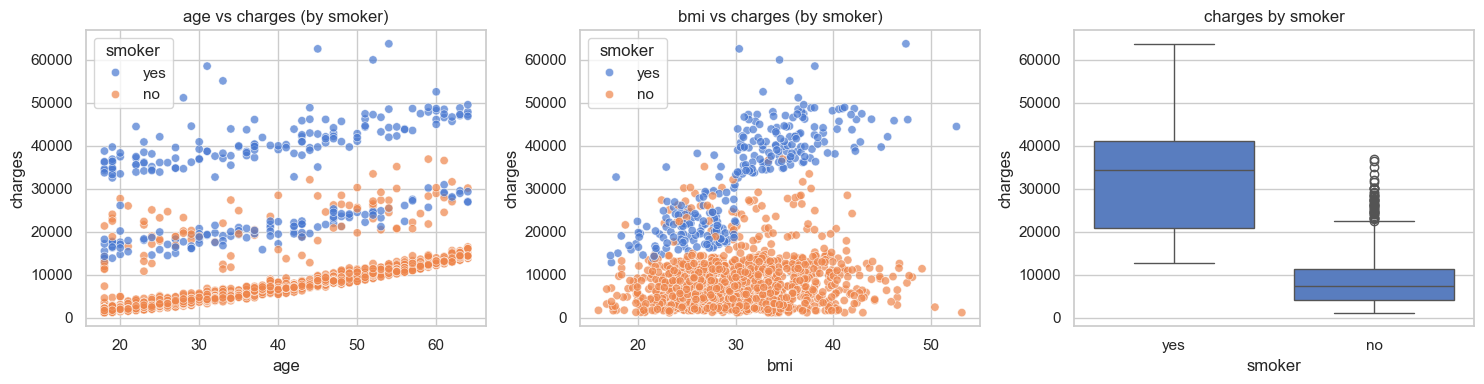

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", alpha=0.7, ax=axes[0])
axes[0].set_title("age vs charges (by smoker)")

sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", alpha=0.7, ax=axes[1])
axes[1].set_title("bmi vs charges (by smoker)")

sns.boxplot(data=df, x="smoker", y="charges", ax=axes[2])
axes[2].set_title("charges by smoker")
plt.tight_layout(); plt.show()

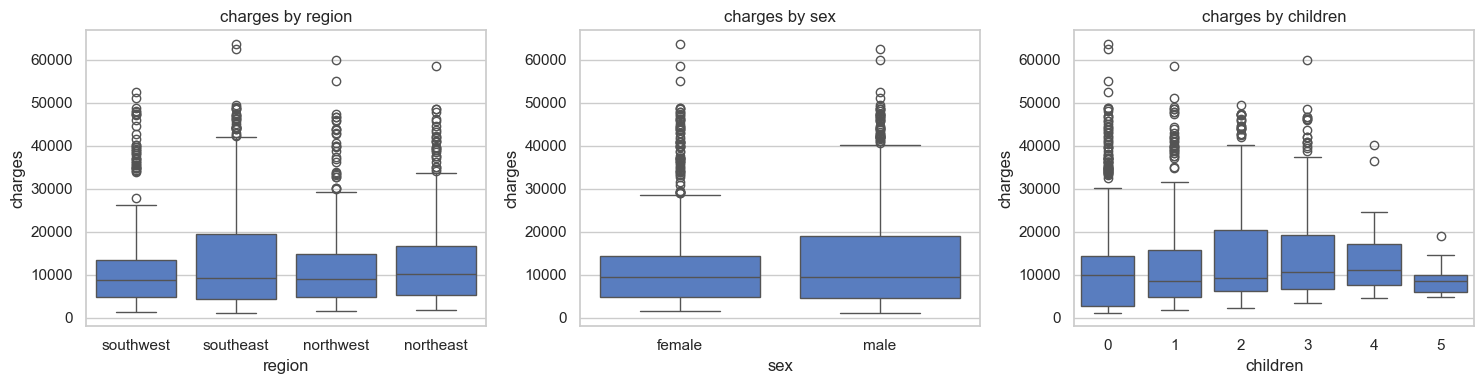

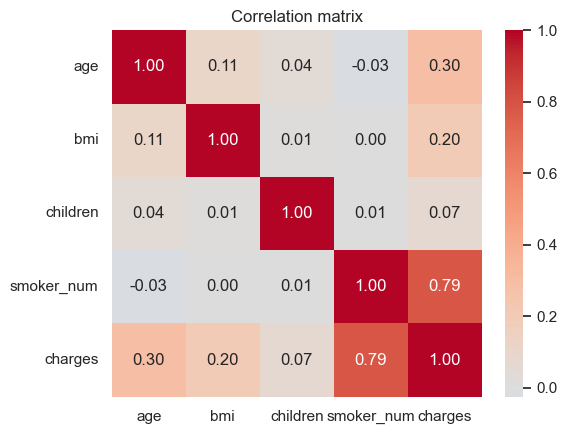

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=df, x="region", y="charges", ax=axes[0]); axes[0].set_title("charges by region")
sns.boxplot(data=df, x="sex", y="charges", ax=axes[1]);    axes[1].set_title("charges by sex")
sns.boxplot(data=df, x="children", y="charges", ax=axes[2]); axes[2].set_title("charges by children")
plt.tight_layout(); plt.show()

# 수치형 상관계수 (smoker를 0/1로 바꿔 함께 확인)
tmp = df.copy()
tmp["smoker_num"] = (tmp["smoker"] == "yes").astype(int)
corr = tmp[["age", "bmi", "children", "smoker_num", "charges"]].corr()
plt.figure(figsize=(6, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix"); plt.tight_layout(); plt.show()

**Q2 답:** `charges`와의 상관계수는 `smoker`(0.79) ≫ `age`(0.30) > `bmi`(0.20) > `children`(0.07) 순

=> 흡연 여부가 중요하고, 성별, 지역에 따른 차이는 크지 않다.

smoker,no,yes
BMI < 30,7977.0,21363.0
BMI >= 30,8843.0,41558.0


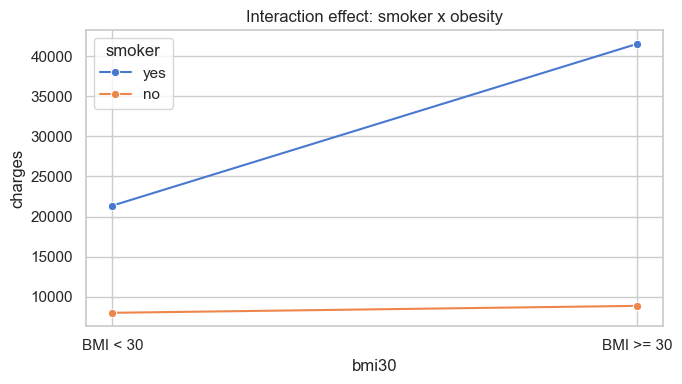

In [7]:
# 상호작용 확인: BMI 30(비만 기준)을 경계로 흡연자/비흡연자의 평균 청구액
tmp["bmi30"] = (tmp["bmi"] >= 30).astype(int)
pivot = tmp.pivot_table(index="bmi30", columns="smoker", values="charges", aggfunc="mean").round(0)
pivot.index = ["BMI < 30", "BMI >= 30"]
display(pivot)

plt.figure(figsize=(7, 4))
sns.lineplot(data=tmp, x="bmi30", y="charges", hue="smoker", marker="o", errorbar=None)
plt.xticks([0, 1], ["BMI < 30", "BMI >= 30"])
plt.title("Interaction effect: smoker x obesity")
plt.tight_layout(); plt.show()

**Q3 답 — 핵심 발견 한가지**

- 비흡연자는 BMI 30을 넘어도 평균 청구액이 거의 오르지 않음 (약 +$560).
- 흡연자는 BMI 30을 넘는 순간 평균 청구액이 **약 2배**로 뜀 (약 $21,000 → $41,000).

=> 이 사실은 bmi vs charges (by smoker) 그래프에서 30을 기준으로 charge가 확 늘어나는 것을 통해 확인이 가능하다.

> **트리 기반 모델(RandomForest, GradientBoosting)이 유리할 것**이라는 가설을 세울 수 있음

## 3. Train / Test 분리 — 전처리보다 **먼저**

### 먼저 나누는 것이 중요한 이유

전처리(스케일링, 인코딩, 결측치 대치 등)의 기준값을 **전체 데이터로 계산하면**  
테스트 데이터의 정보가 학습 과정에 새어 감. 이를 **데이터 누수(data leakage)** 라고 하며,  
테스트 성능이 실제보다 좋게 나오는 대표적인 실수

**원칙: 나누고(split) → 학습 데이터로만 fit → 테스트 데이터에는 transform만.**

In [8]:
X = df.drop(columns="charges")
y = df["charges"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"전체 : {X.shape[0]}건")
print(f"학습 : {X_train.shape[0]}건 ({X_train.shape[0]/len(X):.0%})")
print(f"테스트: {X_test.shape[0]}건 ({X_test.shape[0]/len(X):.0%})")
print(f"\ny_train 평균: {y_train.mean():,.0f} / y_test 평균: {y_test.mean():,.0f}")

전체 : 1338건
학습 : 1070건 (80%)
테스트: 268건 (20%)

y_train 평균: 13,346 / y_test 평균: 12,968


## 4. 전처리 파이프라인 설계

| 변수 유형 | 컬럼 | 처리 | 이유 |
|---|---|---|---|
| 수치형 | `age`, `bmi`, `children` | `StandardScaler` | 선형·규제 모델은 변수 스케일에 민감 (트리 모델엔 영향 없음) |
| 범주형 | `sex`, `smoker`, `region` | `OneHotEncoder` | 문자열은 모델이 직접 못 읽음. 순서가 없는 범주이므로 라벨 인코딩(0,1,2…)은 **부적절** |

`handle_unknown="ignore"` 를 주면 테스트 데이터에 학습 때 없던 범주가 나와도 에러 없이 처리됩니다.

In [10]:
num_features = ["age", "bmi", "children"]
cat_features = ["sex", "smoker", "region"]

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", ohe, cat_features),
    ]
)

# 변환 결과 미리보기
sample = preprocessor.fit_transform(X_train)
feat_names = preprocessor.get_feature_names_out()
print("변환 후 shape:", sample.shape)
pd.DataFrame(sample, columns=feat_names).head()

변환 후 shape: (1070, 11)


,num__age,num__bmi,num__children,cat__sex_female,cat__sex_male,cat__smoker_no,cat__smoker_yes,cat__region_northeast,cat__region_northwest,cat__region_southeast,cat__region_southwest
0,0.472227,-1.756525,0.734336,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0.543313,-1.033082,-0.911192,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
2,0.898745,-0.943687,-0.911192,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,-0.025379,0.622393,3.202629,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,1.040918,-1.504893,1.557100,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


## 5. 베이스라인 모델과 교차검증

### 베이스라인 모델을 만들어놓는 이유
"R² = 0.75" 라는 숫자만 보면 좋은지 나쁜지 알 수 없음  
**대충 작성한 바보 모델(`DummyRegressor`)** 보다 얼마나 나아졌는지를 확인

### 교차검증(K-Fold Cross Validation)
한 번의 train/test 분리는 **어떻게 쪼개졌냐(운)** 에 따라 점수가 출렁일 가능성이 있음.  
K-Fold는 학습 데이터를 K등분해 K번 학습/검증을 반복하고 평균을 냄.  
→ 성능 추정이 안정적으로 변함

> 중요: 교차검증은 **학습 데이터 내부에서만** 수행

In [10]:
kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_report(model, name, X=X_train, y=y_train):
    # 교차검증 RMSE와 R2를 계산해 딕셔너리로 반환
    rmse = -cross_val_score(model, X, y, cv=kfold, scoring="neg_root_mean_squared_error")
    r2   =  cross_val_score(model, X, y, cv=kfold, scoring="r2")
    print(f"{name:<22} RMSE {rmse.mean():>9,.0f} (±{rmse.std():,.0f})   R2 {r2.mean():.4f}")
    return {"model": name, "CV_RMSE": rmse.mean(), "CV_RMSE_std": rmse.std(), "CV_R2": r2.mean()}

results = []
results.append(cv_report(Pipeline([("prep", preprocessor), ("model", DummyRegressor(strategy="mean"))]), "Dummy (mean)"))
results.append(cv_report(Pipeline([("prep", preprocessor), ("model", LinearRegression())]), "LinearRegression"))

Dummy (mean)           RMSE    12,017 (±362)   R2 -0.0042
LinearRegression       RMSE     6,123 (±492)   R2 0.7389


Dummy 모델의 CV RMSE ≈ **12,017** (≈ `charges`의 표준편차)이 우리가 넘어야 할 **최소 기준선**  
R²가 음수(-0.004)인 것도 자연스러운 현상 — 평균만 예측하니 모델의 설명력이 부족하다는 뜻.  
선형회귀는 RMSE ≈ **6,123**으로 절반 수준까지 줄였고, 이제 더 좋은 방법들을 탐색하고 적용합니다.

## 6. 여러 모델 비교

| 모델 | 특징 |
|---|---|
| **Ridge / Lasso** | 선형회귀 + 규제(regularization). 과적합 억제, Lasso는 변수 선택 효과 |
| **DecisionTree** | 비선형·상호작용 학습 가능. 단독으로는 과적합이 심함 |
| **RandomForest** | 여러 트리를 **병렬로** 만들어 평균 (배깅). 안정적이고 튜닝에 관대함 |
| **GradientBoosting** | 트리를 **순차적으로** 쌓아 이전 오차를 보정 (부스팅). 보통 성능이 가장 좋음 |

In [11]:
candidates = {
    "Ridge (alpha=1)":     Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso (alpha=1)":     Lasso(alpha=1.0, random_state=RANDOM_STATE, max_iter=5000),
    "DecisionTree":        DecisionTreeRegressor(random_state=RANDOM_STATE),
    "RandomForest":        RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting":    GradientBoostingRegressor(random_state=RANDOM_STATE),
}

for name, est in candidates.items():
    pipe = Pipeline([("prep", preprocessor), ("model", est)])
    results.append(cv_report(pipe, name))

res_df = pd.DataFrame(results).sort_values("CV_RMSE").reset_index(drop=True)
display(res_df.style.format({"CV_RMSE": "{:,.0f}", "CV_RMSE_std": "{:,.0f}", "CV_R2": "{:.4f}"}))

Ridge (alpha=1)        RMSE     6,123 (±492)   R2 0.7389
Lasso (alpha=1)        RMSE     6,123 (±492)   R2 0.7389
DecisionTree           RMSE     6,509 (±506)   R2 0.7048
RandomForest           RMSE     4,882 (±483)   R2 0.8340
GradientBoosting       RMSE     4,646 (±575)   R2 0.8492


,model,CV_RMSE,CV_RMSE_std,CV_R2
0,GradientBoosting,"4,646",575,0.8492
1,RandomForest,"4,882",483,0.8340
2,Lasso (alpha=1),"6,123",492,0.7389
3,Ridge (alpha=1),"6,123",492,0.7389
4,LinearRegression,"6,123",492,0.7389
5,DecisionTree,"6,509",506,0.7048
6,Dummy (mean),"12,017",362,-0.0042


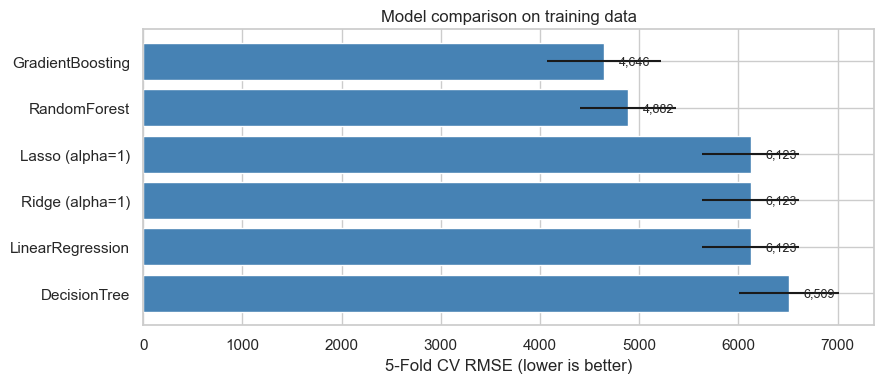

In [12]:
plot_df = res_df[res_df["model"] != "Dummy (mean)"]
plt.figure(figsize=(9, 4))
bars = plt.barh(plot_df["model"], plot_df["CV_RMSE"], xerr=plot_df["CV_RMSE_std"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("5-Fold CV RMSE (lower is better)")
plt.title("Model comparison on training data")
for b, v in zip(bars, plot_df["CV_RMSE"]):
    plt.text(v + 150, b.get_y() + b.get_height()/2, f"{v:,.0f}", va="center", fontsize=9)
plt.tight_layout(); plt.show()

### 📌 결과 해석

- **GradientBoosting**이 가장 좋습니다 (RMSE ≈ 4,600). 2절에서 세운 *"상호작용이 있으니 트리 계열이 유리하다"* 는 가설이 확인되었습니다.
- **DecisionTree** 단독은 선형회귀보다도 나쁩니다. 트리 하나는 학습 데이터를 그대로 외워버려(과적합) 일반화 성능이 떨어집니다. → 앙상블이 필요한 이유.
- **Ridge/Lasso**는 선형회귀와 거의 같습니다. 변수가 6개뿐이라 과적합 문제가 애초에 없어 규제의 효과가 없습니다.

## 7. 하이퍼파라미터 튜닝 (`GridSearchCV`)

**하이퍼파라미터**는 모델이 데이터로부터 학습하는 값이 아니라, **사람이 미리 정해주는 설정값**입니다  
(트리 깊이, 학습률, 트리 개수 등). `GridSearchCV`는 후보 조합을 모두 시도하며  
각각을 **교차검증**으로 평가해 가장 좋은 조합을 찾아줍니다.

In [13]:
gb_pipe = Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])

gb_grid = {
    "model__n_estimators":  [100, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth":     [2, 3, 4],
    "model__subsample":     [0.8, 1.0],
}

gb_search = GridSearchCV(
    gb_pipe, gb_grid, cv=kfold,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1, verbose=0
)
gb_search.fit(X_train, y_train)

print("총 탐색 조합 수 :", len(gb_search.cv_results_["params"]))
print("최적 하이퍼파라미터:")
for k, v in gb_search.best_params_.items():
    print(f"   {k.replace('model__',''):<15} = {v}")
print(f"\n최적 CV RMSE : {-gb_search.best_score_:,.0f}")

총 탐색 조합 수 : 54
최적 하이퍼파라미터:
   learning_rate   = 0.1
   max_depth       = 2
   n_estimators    = 100
   subsample       = 0.8

최적 CV RMSE : 4,506


In [14]:
rf_pipe = Pipeline([("prep", preprocessor),
                    ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
rf_grid = {
    "model__n_estimators":      [300, 600],
    "model__max_depth":         [3, 5, 8, None],
    "model__min_samples_leaf":  [1, 5, 10, 20],
    "model__max_features":      ["sqrt", 1.0],
}
rf_search = GridSearchCV(rf_pipe, rf_grid, cv=kfold,
                         scoring="neg_root_mean_squared_error", n_jobs=-1)
rf_search.fit(X_train, y_train)

print("RandomForest 최적 파라미터:")
for k, v in rf_search.best_params_.items():
    print(f"   {k.replace('model__',''):<18} = {v}")
print(f"최적 CV RMSE : {-rf_search.best_score_:,.0f}")

RandomForest 최적 파라미터:
   max_depth          = 5
   max_features       = 1.0
   min_samples_leaf   = 10
   n_estimators       = 600
최적 CV RMSE : 4,511


In [15]:
# 튜닝 전/후 비교
cmp = pd.DataFrame({
    "모델": ["GradientBoosting", "RandomForest"],
    "튜닝 전 CV RMSE": [res_df.loc[res_df.model=="GradientBoosting","CV_RMSE"].iloc[0],
                        res_df.loc[res_df.model=="RandomForest","CV_RMSE"].iloc[0]],
    "튜닝 후 CV RMSE": [-gb_search.best_score_, -rf_search.best_score_],
})
cmp["개선폭"] = cmp["튜닝 전 CV RMSE"] - cmp["튜닝 후 CV RMSE"]
display(cmp.style.format({"튜닝 전 CV RMSE": "{:,.0f}", "튜닝 후 CV RMSE": "{:,.0f}", "개선폭": "{:+,.0f}"}))

best_model = gb_search.best_estimator_ if gb_search.best_score_ >= rf_search.best_score_ else rf_search.best_estimator_
print("\n선택된 최종 모델:", best_model.named_steps["model"].__class__.__name__)

,모델,튜닝 전 CV RMSE,튜닝 후 CV RMSE,개선폭
0,GradientBoosting,"4,646","4,506",+140
1,RandomForest,"4,882","4,511",+372



선택된 최종 모델: GradientBoostingRegressor


### 📌 튜닝 결과 해석

선택된 GradientBoosting의 최적 조합은 `max_depth=2`, `subsample=0.8`,  
`learning_rate=0.1`, `n_estimators=100` 입니다. 기본값(`max_depth=3`)보다  
**트리를 더 얕게** 만들고 매 단계 데이터의 80%만 사용하도록 제한했다는 점에 주목하세요.  
즉 튜닝의 방향이 "더 복잡하게"가 아니라 **"더 단순하게"** 였고, 이는 기본 설정이  
이 작은 데이터(1,070건)에 과적합하고 있었다는 뜻입니다. CV RMSE 4,646 → 4,506.

RandomForest도 마찬가지로 `max_depth=5`, `min_samples_leaf=10`처럼 트리를 억제하는  
방향으로 최적값이 잡혔고(4,882 → 4,511), 개선폭은 오히려 더 큽니다.  
`min_samples_leaf`(잎 노드가 최소 몇 개의 샘플을 갖게 강제)는 트리 모델에서  
과적합을 막는데 가장 효과적입니다.

두 모델이 튜닝 후 4,506 / 4,511로 거의 같은 값에 수렴한다는 점도 중요합니다.  
**이 데이터에서 뽑아낼 수 있는 신호의 한계에 도달**했다는 신호이며,  
여기서 더 올리려면 모델이 아니라 변수를 손봐야 합니다.

## 8. 최종 모델 평가 (Test set)

**드디어 테스트 데이터를 처음 사용합니다.** 여기서 나온 점수가
"학습에 전혀 쓰이지 않은 새 데이터에 대한 성능" 추정치입니다.

### 회귀 평가지표

| 지표 | 수식 개념 | 해석 |
|---|---|---|
| **RMSE** | 오차 제곱 평균의 제곱근 | 타깃과 같은 단위(달러). 큰 오차에 더 큰 벌점 |
| **MAE** | 오차 절댓값의 평균 | 이상치에 덜 민감. "평균적으로 몇 달러 틀리는가" |
| **R²** | 1 - (모델 오차 / 평균 예측 오차) | 0~1. "타깃 분산의 몇 %를 설명하는가" |

In [16]:
def evaluate(model, X_tr, y_tr, X_te, y_te, name="model"):
    model.fit(X_tr, y_tr)
    pred_tr, pred_te = model.predict(X_tr), model.predict(X_te)
    out = {
        "model": name,
        "Train RMSE": np.sqrt(mean_squared_error(y_tr, pred_tr)),
        "Test RMSE":  np.sqrt(mean_squared_error(y_te, pred_te)),
        "Test MAE":   mean_absolute_error(y_te, pred_te),
        "Train R2":   r2_score(y_tr, pred_tr),
        "Test R2":    r2_score(y_te, pred_te),
    }
    return out, pred_te

lin_pipe = Pipeline([("prep", preprocessor), ("model", LinearRegression())])

final_rows = []
row_lin, pred_lin = evaluate(lin_pipe, X_train, y_train, X_test, y_test, "LinearRegression (baseline)")
row_best, pred_best = evaluate(best_model, X_train, y_train, X_test, y_test, "Tuned best model")
final_rows += [row_lin, row_best]

final_df = pd.DataFrame(final_rows)
display(final_df.style.format({
    "Train RMSE": "{:,.0f}", "Test RMSE": "{:,.0f}", "Test MAE": "{:,.0f}",
    "Train R2": "{:.4f}", "Test R2": "{:.4f}"}))

,model,Train RMSE,Test RMSE,Test MAE,Train R2,Test R2
0,LinearRegression (baseline),"6,106","5,796","4,181",0.7417,0.7836
1,Tuned best model,"4,179","4,342","2,442",0.8790,0.8785


### 📌 과적합 진단법

`Train RMSE`와 `Test RMSE`의 **격차**를 봅니다.

- 격차가 거의 없다 → 적절히 일반화됨 (또는 과소적합)
- Train은 아주 좋은데 Test가 나쁘다 → **과적합**. 모델을 단순하게 하거나 데이터를 늘려야 함

튜닝된 모델은 **Train R² 0.879 / Test R² 0.879** 로 격차가 사실상 없습니다.  
반면 튜닝하지 않은 DecisionTree는 같은 분할에서 **Train R² 0.998 / Test R² 0.756** 입니다.  
학습 데이터는 거의 통째로 외웠는데 새 데이터에는 약한, 교과서적인 과적합입니다.

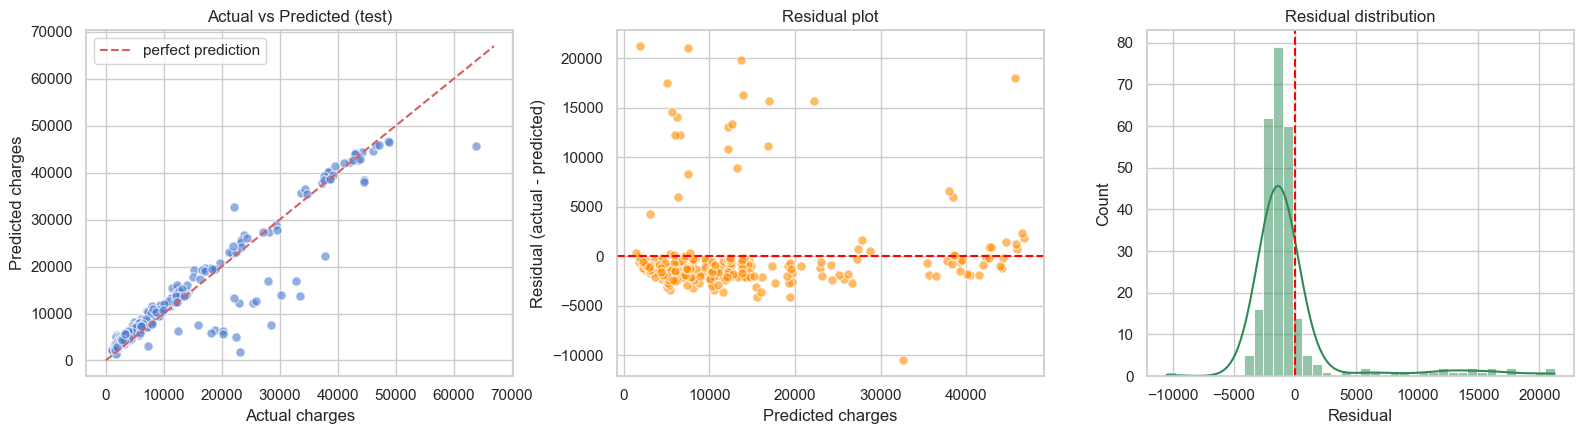

잔차 평균: -198 / 잔차 표준편차: 4,346


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (1) 실제 vs 예측
axes[0].scatter(y_test, pred_best, alpha=0.6, edgecolor="w", s=45)
lims = [0, max(y_test.max(), pred_best.max()) * 1.05]
axes[0].plot(lims, lims, "r--", lw=1.5, label="perfect prediction")
axes[0].set_xlabel("Actual charges"); axes[0].set_ylabel("Predicted charges")
axes[0].set_title("Actual vs Predicted (test)"); axes[0].legend()

# (2) 잔차 플롯
resid = y_test - pred_best
axes[1].scatter(pred_best, resid, alpha=0.6, edgecolor="w", s=45, color="darkorange")
axes[1].axhline(0, color="red", ls="--", lw=1.5)
axes[1].set_xlabel("Predicted charges"); axes[1].set_ylabel("Residual (actual - predicted)")
axes[1].set_title("Residual plot")

# (3) 잔차 분포
sns.histplot(resid, bins=40, kde=True, ax=axes[2], color="seagreen")
axes[2].axvline(0, color="red", ls="--")
axes[2].set_title("Residual distribution"); axes[2].set_xlabel("Residual")

plt.tight_layout(); plt.show()
print(f"잔차 평균: {resid.mean():,.0f} / 잔차 표준편차: {resid.std():,.0f}")

### 📌 잔차 플롯 읽는 법

이상적인 잔차 플롯은 **0을 중심으로 무작위하게 흩어진 구름**입니다.  
패턴이 보이면 모델이 아직 잡아내지 못한 구조가 남아 있다는 뜻입니다.

이 데이터에서는 잔차가 위쪽으로 크게 튀는 소수의 점들이 보입니다.  
이는 **`age`, `bmi`, `smoker`만으로는 설명되지 않는 고액 청구자**(중병, 사고 등)이며,  
현재 데이터셋에 그 정보(진단명, 병력 등)가 없기 때문에 구조적으로 예측 불가능한 부분입니다.  
→ 성능을 더 올리려면 모델이 아니라 **데이터(변수)를 더 확보**해야 합니다.

## 9. 모델 해석 — 특성 중요도 (Feature Importance)

트리 모델의 기본 `feature_importances_`는 **카디널리티가 높은(값 종류가 많은) 변수를 과대평가**하는  
편향이 있습니다. 더 신뢰할 수 있는 방법은 **순열 중요도(Permutation Importance)** 입니다.

> 원리: 특정 변수의 값만 무작위로 섞어서 관계를 깨뜨린 뒤 성능이 얼마나 떨어지는지 측정  
> 많이 떨어질수록 그 변수가 중요했다는 뜻으로 어떤 모델에도 적용 가능합니다.

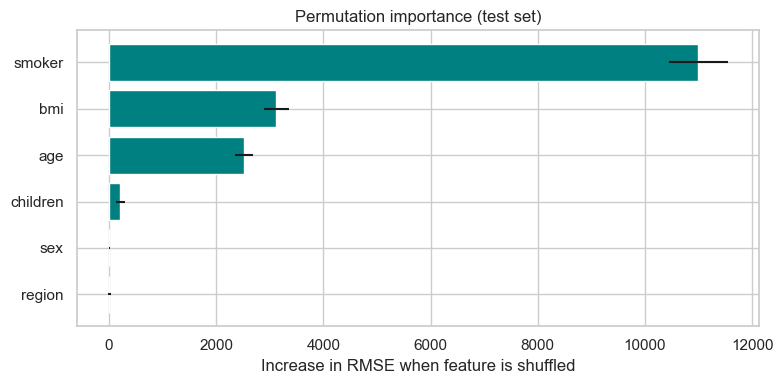

,feature,importance,std
0,smoker,10995.615472,551.974895
1,bmi,3123.571637,237.606791
2,age,2518.351028,173.857829
3,children,211.104747,76.100849
4,sex,2.245397,9.138953
5,region,1.674829,25.829383


In [18]:
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE, scoring="neg_root_mean_squared_error"
)
imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean,
    "std": perm.importances_std,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(imp["feature"], imp["importance"], xerr=imp["std"], color="teal")
plt.gca().invert_yaxis()
plt.xlabel("Increase in RMSE when feature is shuffled")
plt.title("Permutation importance (test set)")
plt.tight_layout(); plt.show()
display(imp.reset_index(drop=True))

### 📌 비즈니스 해석

1. **`smoker`가 압도적 1위** — 흡연 정보를 지우면 RMSE가 수천 달러 악화됩니다.  
   보험 언더라이팅에서 흡연 여부를 가장 중요하게 묻는 이유가 데이터로 확인됩니다.
2. **`bmi`, `age`가 2·3위** — 나이와 체질량은 꾸준한 위험 요인입니다.
3. **`sex`, `region`은 사실상 0** — 이 데이터에서는 성별·지역이 보험료를 거의 설명하지 못합니다.  
   (참고: 성별을 요율에 반영하는 것은 여러 국가에서 규제 대상이기도 합니다.)

## 10. 피처 엔지니어링으로 선형모델 개선하기

2절에서 발견한 **`smoker` × `bmi30` 상호작용**을 변수로 직접 만들어주면,  
단순한 선형회귀도 트리 모델에 근접할 수 있습니다.  
"좋은 변수 하나가 복잡한 모델 하나보다 낫다"는 것을 보여주는 실습입니다.

In [ ]:
def add_features(data: pd.DataFrame) -> pd.DataFrame:
    d = data.copy()
    d["bmi30"] = (d["bmi"] >= 30).astype(int)          # 비만 여부
    d["smoker_num"] = (d["smoker"] == "yes").astype(int)
    d["smoker_bmi30"] = d["bmi30"] * d["smoker_num"]   # ★ 상호작용 항
    d["smoker_bmi"] = d["smoker_num"] * d["bmi"]       # 연속형 상호작용
    d["age2"] = d["age"] ** 2                          # 나이의 비선형 효과
    return d.drop(columns=["smoker_num"])

X_train_fe, X_test_fe = add_features(X_train), add_features(X_test)

num_fe = ["age", "bmi", "children", "bmi30", "smoker_bmi30", "smoker_bmi", "age2"]
ohe2 = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor_fe = ColumnTransformer([
    ("num", StandardScaler(), num_fe),
    ("cat", ohe2, cat_features),
])

lin_fe = Pipeline([("prep", preprocessor_fe), ("model", LinearRegression())])
row_fe, _ = evaluate(lin_fe, X_train_fe, y_train, X_test_fe, y_test, "LinearRegression + FE")

compare_df = pd.DataFrame([row_lin, row_fe, row_best])
display(compare_df.style.format({
    "Train RMSE": "{:,.0f}", "Test RMSE": "{:,.0f}", "Test MAE": "{:,.0f}",
    "Train R2": "{:.4f}", "Test R2": "{:.4f}"}))

,model,Train RMSE,Test RMSE,Test MAE,Train R2,Test R2
0,LinearRegression (baseline),"6,106","5,796","4,181",0.7417,0.7836
1,LinearRegression + FE,"4,392","4,262","2,316",0.8664,0.8830
2,Tuned best model,"4,179","4,342","2,442",0.8790,0.8785


In [20]:
# 상호작용 항을 넣은 선형모델의 회귀계수 확인 (해석 가능성이 선형모델의 장점)
lin_fe.fit(X_train_fe, y_train)
names = lin_fe.named_steps["prep"].get_feature_names_out()
coefs = pd.DataFrame({"feature": names, "coef": lin_fe.named_steps["model"].coef_})
coefs["abs"] = coefs["coef"].abs()
display(coefs.sort_values("abs", ascending=False).drop(columns="abs").head(10).reset_index(drop=True))

,feature,coef
0,num__smoker_bmi,5861.833133
1,num__smoker_bmi30,4788.626187
2,num__age2,3732.911156
3,num__children,739.811176
4,cat__smoker_yes,722.126453
5,cat__smoker_no,-722.126453
6,cat__region_southwest,-706.265320
7,cat__region_northeast,630.161308
8,cat__sex_male,-278.369801
9,cat__sex_female,278.369801


### 📌 결과

선형회귀의 Test R²가 **0.784 → 0.883** 으로 뛰었습니다.  
하이퍼파라미터를 54가지 조합이나 탐색한 GradientBoosting(0.879)을 **오히려 근소하게 앞섭니다.**  
변수 몇 개를 손으로 만든 것이 수십 번의 튜닝보다 효과가 컸다는 뜻입니다.  
회귀계수를 보면 `smoker_bmi30`(비만인 흡연자) 항의 계수가 가장 크고 양수인데,  
이는 *"흡연자이면서 비만일 때 추가로 얼마나 더 청구되는가"* 를 직접 읽을 수 있다는 뜻입니다.  

- **트리 모델**: 상호작용을 자동으로 학습하지만 계수처럼 딱 떨어지게 해석하기 어려움
- **선형 모델 + 좋은 피처**: 성능은 비슷하면서 **설명 가능**

보험료 산정처럼 **고객·감독기관에 근거를 설명해야 하는 도메인**에서는 후자가 선택되기도 합니다.